In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('car_price.csv')
df.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5512 non-null   int64 
 1   car_name             5512 non-null   object
 2   car_prices_in_rupee  5512 non-null   object
 3   kms_driven           5512 non-null   object
 4   fuel_type            5512 non-null   object
 5   transmission         5512 non-null   object
 6   ownership            5512 non-null   object
 7   manufacture          5512 non-null   int64 
 8   engine               5512 non-null   object
 9   Seats                5512 non-null   object
dtypes: int64(2), object(8)
memory usage: 430.8+ KB


                                         car_name car_prices_in_rupee
119        Land Rover Discovery 2.0 R-Dynamic HSE          1.10 Crore
238                          Maruti Swift 1.3 LXI             99,999 
243                                 Maruti Zen LX             55,000 
315                             BMW X7 xDrive 40i          1.23 Crore
342                         Maruti Alto LXi BSIII             84,778 
...                                           ...                 ...
5438  Land Rover Range Rover Sport 2.0 Petrol HSE          1.14 Crore
5439                                 Maruti Zen D             80,000 
5458                       Toyota Land Cruiser VX          1.69 Crore
5482                      Mercedes-Benz G G63 AMG          1.52 Crore
5483                         Porsche Panamera GTS          1.75 Crore

[179 rows x 2 columns]
Values found with no unit label:
['99,999 ' '55,000 ' '84,778 ' '59,000 ' '90,000 ' '99,205 ' '60,000 '
 '65,000 ' '89,000 ' '45,000 ' '

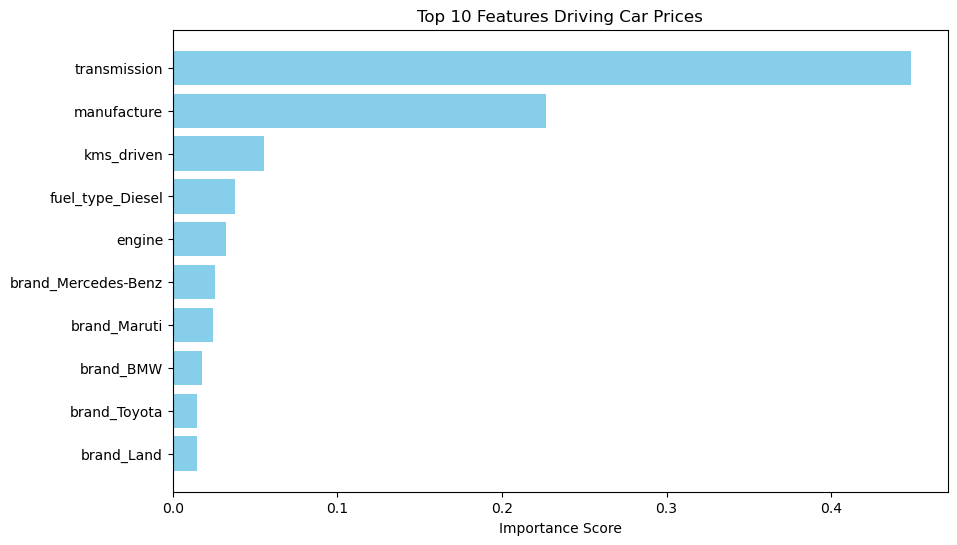

In [ ]:


non_lakh_cars = df[~df['car_prices_in_rupee'].str.contains('Lakh', na=False)]

# Print the car names and their weird prices(rupees,lakh,crore)
print(non_lakh_cars[['car_name', 'car_prices_in_rupee']])

# Create a filter for rows that DON'T have 'Lakh' AND DON'T have 'Crore'
no_unit_rows = df[~(df['car_prices_in_rupee'].str.contains('Lakh', na=False)) & 
                  ~(df['car_prices_in_rupee'].str.contains('Crore', na=False))]

print("Values found with no unit label:")
print(no_unit_rows['car_prices_in_rupee'].unique())

print(f"\nTotal rows without a unit: {len(no_unit_rows)}")



df.shape



df.info()



df['fuel_type'].value_counts()



df['transmission'].value_counts()



df['ownership'].value_counts()



df['Seats'].value_counts()



df.drop(columns=['Unnamed: 0'], axis=1, inplace=True)
# 2. Extract the Brand (e.g., "Jeep", "Renault", "Toyota")
# We take the first word from the 'car_name' string
df['brand'] = df['car_name'].str.split(' ').str[0]
df.drop(columns=['car_name'], axis=1, inplace=True)
df['brand'].nunique()
32
# Keep all rows EXCEPT '0th Owner'
df = df[df['ownership'] != '0th Owner'].copy()
print(df['ownership'].value_counts())



df.shape


df.describe()



df.dtypes




# cols = ['kms_driven', 'engine', 'Seats', 'ownership', 'car_prices_in_rupee']

# # Replace anything that isn't a number or decimal point, then convert to float
# df[cols] = df[cols].replace(r'[^\d.]', '', regex=True).astype(float)
cols = ['kms_driven', 'engine', 'Seats', 'ownership']

# 2. Strip out all text and commas, and convert to float (Your original code)
df[cols] = df[cols].replace(r'[^\d.]', '', regex=True).astype(float)
def standardize_price(value):
    # 1. Convert to string and clean up spaces/commas
    value = str(value).replace(',', '').strip()
    
    # 2. Handle Crore
    if 'Crore' in value:
        num = float(value.replace('Crore', '').strip())
        return num * 100  # Convert Crore to Lakhs
    
    # 3. Handle Lakh
    elif 'Lakh' in value:
        num = float(value.replace('Lakh', '').strip())
        return num  # Already in Lakhs
    
    # 4. Handle Raw Rupees (Values like 99999, 55000)
    else:
        try:
            num = float(value)
            # If it's a large number like 99,000, it's Rupees.
            # We divide by 100,000 to get it into Lakhs (e.g., 0.99)
            if num > 1000: 
                return num / 100000
            else:
                return num # If it's already a small number, assume Lakhs
        except ValueError:
            return None # Handle any unexpected text like "Price on Request"

# Apply to the column
df['car_prices_in_rupee'] = df['car_prices_in_rupee'].apply(standardize_price)
df.dtypes



df.describe()




df.head()



df['transmission'] = df['transmission'].map({'Manual': 0, 'Automatic': 1})


# 2. One-Hot Encoding for Fuel Type
df = pd.get_dummies(df, columns=['fuel_type'], drop_first=True, dtype=int)

# Convert brands into numeric columns (e.g., brand_Jeep, brand_Toyota)
df = pd.get_dummies(df, columns=['brand'], drop_first=True, dtype=int)
df.head()




X = df.drop('car_prices_in_rupee', axis=1)
y = df['car_prices_in_rupee']
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} Lakhs")
print(f"R-squared Score (R2): {r2:.2f}")




from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE: {rf_mae:.2f} Lakhs")
print(f"Random Forest R-squared: {rf_r2:.2f}")




import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

y_train_log = np.log1p(y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_log)

rf_pred_log = rf_model.predict(X_test_scaled)

rf_pred_final = np.expm1(rf_pred_log)

rf_mae = mean_absolute_error(y_test, rf_pred_final)
rf_r2 = r2_score(y_test, rf_pred_final)

print(f"Random Forest (Log-Transformed) MAE: {rf_mae:.2f} Lakhs")
print(f"Random Forest (Log-Transformed) R-squared: {rf_r2:.4f}")




import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Driving Car Prices')
plt.gca().invert_yaxis()
plt.show()